In [3]:
import os, re, glob, math
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from Bio.SeqIO.FastaIO import SimpleFastaParser as sfp
import subprocess as sp
from Bio import SeqIO
import seaborn as sns
import pandas as pd

In [4]:
def cmdir(path):
    if not os.path.isdir(path):
        os.mkdir(path)

def sbatch(name, cpus, cmd):
    return "sbatch -J %s -p serc -t 1- -c %d --mem %dG --wrap '%s'" %(name, cpus, cpus*8, cmd)

In [5]:
rootdir = "/scratch/users/ajaffe/ocdata/"
cmdir(rootdir)

## refine genome set

In [4]:
cmdir(rootdir + "tables")
cmdir(rootdir + "genomes")

### base

In [6]:
site_dict = {"A500":"OC2", "A3000":"OC3", 
             "A3500":"OC4", "A4000":"OC5", "A4500": "OC6"}

In [ ]:
base = pd.read_csv(rootdir + "tables/prelim_genomes_v2.tsv", sep="\t")
base.head()

### jaffe and arandia-gorostidi

In [5]:
cmdir(rootdir + "genomes/jaffe_arandia")

Move genomes from drive into here.

In [6]:
inverse_dict = {value:key for key, value in site_dict.items()}
jaffe_arandia_info = defaultdict(list)

for genome in glob.glob(rootdir + "genomes/jaffe_arandia/*fa"):
    
    name = os.path.basename(genome).split(".")[0]
    osite = inverse_dict[name.split("_")[0]]
    oldname = osite + "m" + name.split("_")[1] + "." + name.split("_")[3]
    
    jaffe_arandia_info["original_bin_name"].append(oldname)
    jaffe_arandia_info["refined_bin_name"].append(name)

jaffe_arandia_df = pd.DataFrame(jaffe_arandia_info)
jaffe_arandia_df.head()

,original_bin_name,refined_bin_name
0,A3000m3000m.167,OC3_3000m_MAG_167
1,A4500m2000m.74,OC6_2000m_MAG_74
2,A4500m4000m.189,OC6_4000m_MAG_189
3,A3000m500m.46,OC3_500m_MAG_46
4,A4500m2000m.87,OC6_2000m_MAG_87


### salcedo et al

In [9]:
cmdir(rootdir + "genomes/salcedo")

In [10]:
# read in assembly conversion dicts
scaffold_dict = {}

for assembly in glob.glob("/oak/stanford/groups/dekas/anvio/oc17/assembly.d/*m.scaffolds.txt"):
    
    name = os.path.basename(assembly).split(".")[0]
    
    scaffold_dict[name] = {}
    
    for line in open(assembly).readlines():
        s = line.strip().split("\t")
        scaffold_dict[name][s[1]] = {"old_name":s[0], "len":s[2]}

In [11]:
salcedo_genome_info = defaultdict(list)

for file in glob.glob("/oak/stanford/groups/dekas/people/rebecca/OC17_deepauto/refined_bins/*"):
    
    name = os.path.basename(file).replace("R", "A").split("_")[0]
    site = site_dict[name.split("m")[0]]
    newname = "_".join([site, name.split("m")[1] + "m", "MAG", name.split(".")[1]])
    
    with open(rootdir + "genomes/salcedo/" + newname + ".fa", "w") as out:
        
        for record in sfp(open(file)):
            
            current_len = len(record[1])
            matched_len = int(scaffold_dict[name.split(".")[0]][record[0]]["len"])
            matched_name = scaffold_dict[name.split(".")[0]][record[0]]["old_name"]
            clean_name = site + "_" + "_".join([item for item in \
                matched_name.split("_")[2:] if item != "sens"])
            
            if current_len == matched_len:
                out.write(">%s\n%s\n" %(clean_name, record[1]))
                
    salcedo_genome_info["original_bin_name"].append(name)
    salcedo_genome_info["refined_bin_name"].append(newname)
    
salcedo_genome_df = pd.DataFrame(salcedo_genome_info)
salcedo_genome_df.head()

,original_bin_name,refined_bin_name
0,A4500m150m.240,OC6_150m_MAG_240
1,A4000m150m.209,OC5_150m_MAG_209
2,A4000m150m.237,OC5_150m_MAG_237
3,A4500m4000m.208,OC6_4000m_MAG_208
4,A500m50m.289,OC2_50m_MAG_289


In [18]:
# remove previously curated genomes from jaffe-arandia
salcedo_genome_df = salcedo_genome_df[~salcedo_genome_df["original_bin_name"].isin(jaffe_arandia_df["original_bin_name"].unique())]

In [19]:
scaffold_dict = {}

### reconcile metadata

In [20]:
concat = pd.concat([jaffe_arandia_df, salcedo_genome_df])

In [21]:
merged = base.merge(concat, how="left", left_on="user_genome", 
                    right_on="original_bin_name").fillna("None").drop("original_bin_name", axis=1)
merged["refined"] = merged["refined_bin_name"].apply(lambda x: True if x != 'None' else False)

remaining = merged[(merged["checkm_completeness"]>=50) & (merged["checkm_redundancy"]<=25) & \
       (merged["secondary_cluster_representative"]==True) & (merged["refined"]==False)]
remaining.shape

(875, 14)

## refine

### set up anvio

In [15]:
adir = rootdir + "anvio/"
cmdir(adir)
cmdir(adir + "/assembly.d/")
cmdir(adir + "/contig.db/")
cmdir(adir + "profiles")
cmdir(adir + "profiles/merged")
cmdir(adir + "profiles/split")
cmdir(adir + "binning")
cmdir(adir + "binning/scaf2bin")

Copy relevant files from $OAK into each one of these.

### add bin information

In [52]:
cmdir(rootdir + "genomes/raw")

In [56]:
# move over subset of genomes from drive
with open(rootdir + "genomes/drive_pull.txt", "w") as out:
    
    for key, row in remaining.iterrows():
        out.write("%s\n" %(row["user_genome"] + ".fa"))

In [57]:
cmd = "rclone copy drive:oc17/dereplicated_genomes_v2/ raw/ --files-from drive_pull.txt --dry-run"
print(cmd)

rclone copy drive:oc17/dereplicated_genomes_v2/ raw/ --files-from drive_pull.txt --dry-run


In [15]:
# generate scaf2bin for drep genomes
dscaf2bin = {}

for bin in glob.glob(rootdir + "genomes/raw/*"):
    for record in SeqIO.parse(open(bin), "fasta"):
        dscaf2bin[record.description.split(" ")[0]] = os.path.basename(bin)

# read into df     
ddf = pd.DataFrame.from_dict(dscaf2bin, orient="index").reset_index()
ddf.columns = ["scaffold", "bin"]

In [16]:
# write out sample specific scaf2bins
ddf["sample"] = ddf["bin"].apply(lambda x: x.split(".")[0])

for sample in ddf["sample"].unique():
    with open(adir + "binning/scaf2bin/" + sample + ".scaf2bin.txt", "w") as outfile:
        lookup = {line.split("\t")[0]: line.split("\t")[1] \
             for line in open(rootdir + "anvio/assembly.d/" + sample + ".scaffolds.txt").readlines()}
        for key, row in ddf[ddf["sample"]==sample].iterrows():
            new_bin = row["bin"].replace(".", "_")
            outfile.write(lookup[row["scaffold"]] + "\t" + new_bin + "\n")

In [ ]:
# import collection to anvio
with open(adir + "binning/importcollections.sh", "w") as out:
    for db in glob.glob(adir + "contig.db/A4500m50m.contig.db"):
        name = os.path.basename(db).replace(".contig.db", "")
        scaf2bin = glob.glob(adir + "binning/scaf2bin/*" + name + "*")
        if scaf2bin != []:
            call = "singularity exec /home/groups/dekas/software/anvio/anvio_7.sif anvi-import-collection --contigs-mode " + scaf2bin[0] + " -p " + adir + "/profiles/merged/" + \
                name + "-MERGED/PROFILE.db -c " + db + " -C 'OCDATA'"
            #out.write(call + "\n")
            print(call)

In [ ]:
## finally, split merged profiles to be bin specific
## this speeds up the refine load by 10x but takes a while
with open(adir + "binning/split.sh", "w") as outfile:
    for db in glob.glob(adir + "contig.db/A4500m*contig.db"):
        name = os.path.basename(db).replace(".contig.db", "")
        call = "singularity exec /home/groups/dekas/software/anvio/anvio_7.sif anvi-split -p %s -c %s -C OCDATA -o %s" \
            %(rootdir + "anvio/profiles/merged/" + name + "-MERGED/PROFILE.db", 
              rootdir + "anvio/contig.db/" + name + ".contig.db", rootdir + "anvio/profiles/split/" + name)
        #outfile.write(call + "\n")
        print(sbatch("anvio", 4, call))

In [17]:
## fix split databases to work with version 7 anvio (thanks meren!)
sif = "singularity exec /home/groups/dekas/software/anvio/anvio_7.sif"

count = 0

with open(rootdir + "anvio/profiles/split/mend.sh", "w") as out:

    for splitdir in glob.glob(rootdir + "anvio/profiles/split/A4500*"):

        for profile in glob.glob(splitdir + "/*"):

            contigs = profile + "/" + "CONTIGS.db"
            fasta = profile + "/" + "contigs.fa"
            export = "%s anvi-export-contigs -c %s -o %s" %(sif, contigs, fasta)
            sql1 = '''PROJECT_NAME=$(sqlite3 %s "SELECT value FROM self WHERE key = 'project_name';")''' %(contigs)
            sql2 = '''HASH=$(sqlite3 %s "SELECT value FROM self WHERE key = 'contigs_db_hash';")''' %(contigs)
            regen = "rm -rf %s && %s anvi-gen-contigs-database -f %s -o %s -T 4 --project-name $PROJECT_NAME" %(contigs, sif, fasta, contigs)
            sql3 = '''sqlite3 %s "UPDATE self SET value = '$HASH' WHERE key = 'contigs_db_hash';"''' %(contigs)
            hmms = "%s anvi-run-hmms -c %s -T 4 && rm -rf %s" %(sif, contigs, fasta)
            out.write("\n".join([export, sql1, sql2, regen, sql3, hmms]) + "\n")
            count+=1
            
print(count)

296


### do the refine

In [26]:
cmdir(adir + "refine")

In [18]:
# base refine command
# log in to biotite with ssh -L 8080:localhost:8080 ajaffe@sherlock.stanford.edu
remaining["sample"] = remaining["user_genome"].apply(lambda x: x.split(".")[0])

for sample in remaining["sample"].unique():
    
    if "A4500m" in sample:
        
        table = remaining[remaining["sample"]==sample]
        out = open(adir + "refine/" + sample + "_calls.txt", "w")

        for key, row in table.iterrows():

            slug = row["user_genome"].split(".")[0]
            new_bin = row["user_genome"].replace(".","_") + "_fa"
            call = "singularity exec /home/groups/dekas/software/anvio/anvio_7.sif anvi-refine -p %sprofiles/split/%s/%s/PROFILE.db -c %s/profiles/split/%s/%s/CONTIGS.db -C DEFAULT --show-all-layers --server-only -P 8080" %(adir, slug, new_bin, adir, slug, new_bin)
            out.write(call + "\n")

        out.close()

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [19]:
# export refined bins
with open(rootdir + "anvio/refine/export_bybin.sh", "w") as out:
    for bindir in glob.glob(rootdir + "anvio/profiles/split/*/*"):
        #if os.path.basename(bindir) in test:
        call = "singularity exec /home/groups/dekas/software/anvio/anvio_7.sif anvi-export-collection -p " + bindir + "/PROFILE.db -C DEFAULT -O " + bindir + "/" + bindir.split("/")[-1]
        out.write(call + "\n")

### write out fastas

In [16]:
cmdir(rootdir + "genomes/ocdata")

In [44]:
# read in assembly conversion dicts
scaffold_dict = {}

for assembly in glob.glob("/oak/stanford/groups/dekas/anvio/oc17/assembly.d/*m.scaffolds.txt"):
    
    name = os.path.basename(assembly).split(".")[0]
    
    scaffold_dict[name] = {}
    
    for line in open(assembly).readlines():
        s = line.strip().split("\t")
        scaffold_dict[name][s[1]] = {"old_name":s[0], "len":s[2]}

In [ ]:
for bindir in glob.glob(rootdir + "anvio/profiles/split/*/*/"):
    
    scafs = glob.glob(bindir + "*fa.txt")
    
    if scafs != []:
        
        table = pd.read_csv(scafs[0], sep="\t", header=None)
        name = bindir.split("/")[-2].replace("_fa", "")
        site = site_dict[name.split("m")[0]]
        newname = "_".join([site, name.split("m")[1] + "m", "MAG", name.split("_")[1]])
        to_remove = []
        
        # identify scaffolds to trim from original
        
        if len(table[1].unique()) > 1:
            
            # if multiple refined, take first - small #
            refined = table[table[1]!="ALL_SPLITS"][1].iloc[0]
            refined_scafs = list(table[table[1]==refined][0])
            original_scafs = list(table[table[1]=='ALL_SPLITS'][0])
            diff = set(original_scafs).difference(refined_scafs)
            
            for item in diff:
                
                try:
                    old_contig = scaffold_dict[name.split("_")[0]][item.split("_split_")[0]]["old_name"]
                    to_remove.append(old_contig)
    
                except: print(item + " couldn't be found in corresponding dictionary.")
            
        else: pass
            
        # now actually write the new bins
        with open(rootdir + "genomes/ocdata/" + newname + ".fa", "w") as out:
            
            gpath = rootdir + "genomes/raw/" + name.replace("_", ".") + ".fa"
            
            for record in sfp(open(gpath)):
                if record[0] not in to_remove:
                    edited = record[0].replace("sens_", "").replace("OC1703_","")
                    edited = edited.replace(edited.split("_")[0], \
                                            site_dict["A" + edited.split("_")[0].replace("m","")], 1)
                    out.write(">%s\n%s\n" %(edited, record[1]))

### quantify the differences

In [69]:
cmdir(rootdir + "genomes/all_refined")

Combine all three dirs into here.

In [22]:
# get remaining originals from drive
representatives = merged.query("secondary_cluster_representative==True")

with open(rootdir + "genomes/drive_pull.txt", "w") as out:
    
    for key, row in representatives.query("refined==True").iterrows():
        out.write("%s\n" %(row["user_genome"] + ".fa"))
        
cmd = "rclone copy drive:oc17/dereplicated_genomes_v2/ raw/ --files-from drive_pull.txt"
print(cmd)

rclone copy drive:oc17/dereplicated_genomes_v2/ raw/ --files-from drive_pull.txt


In [23]:
refine_info = defaultdict(list)

for key, row in representatives.iterrows():
    
    original = rootdir + "genomes/raw/" + row["user_genome"] + ".fa"
    site = site_dict[row["user_genome"].split("m")[0]]
    newname = "_".join([site, row["user_genome"].split("m")[1] + "m", \
                        "MAG", row["user_genome"].split(".")[1]])
    refined = rootdir + "genomes/all_refined/" + newname + ".fa"
    
    o_nscafs = len([record for record in sfp(open(original))])
    r_nscafs = len([record for record in sfp(open(refined))])
    o_binlen = sum([len(record[1]) for record in sfp(open(original))])
    r_binlen = sum([len(record[1]) for record in sfp(open(refined))])
    
    refine_info["bin_name"].append(newname)
    refine_info["original_name"].append(row["user_genome"])
    refine_info["original_nscafs"].append(o_nscafs)
    refine_info["refined_nscafs"].append(r_nscafs)
    refine_info["delta_nscafs"].append(o_nscafs-r_nscafs)
    refine_info["delta_nscafs_perc"].append((o_nscafs-r_nscafs)/(o_nscafs)*100)
    refine_info["original_binlen"].append(o_binlen)
    refine_info["refined_binlen"].append(r_binlen)
    refine_info["delta_binlen"].append(o_binlen-r_binlen)
    refine_info["delta_binlen_perc"].append((o_binlen-r_binlen)/(o_binlen)*100)
    
refine_df = pd.DataFrame(refine_info)
refine_df

,bin_name,original_name,original_nscafs,refined_nscafs,delta_nscafs,delta_nscafs_perc,original_binlen,refined_binlen,delta_binlen,delta_binlen_perc
0,OC6_150m_MAG_161,A4500m150m.161,190,176,14,7.368421,1110207,1073987,36220,3.262455
1,OC6_500m_MAG_275,A4500m500m.275,376,289,87,23.138298,988237,778693,209544,21.203821
2,OC6_150m_MAG_54,A4500m150m.54,268,233,35,13.059701,1759658,1684499,75159,4.271228
3,OC6_50m_MAG_211,A4500m50m.211,256,256,0,0.000000,1966416,1966416,0,0.000000
4,OC4_50m_MAG_286,A3500m50m.286,329,301,28,8.510638,1651766,1571583,80183,4.854380
...,...,...,...,...,...,...,...,...,...,...
1190,OC6_150m_MAG_320,A4500m150m.320,655,655,0,0.000000,2179326,2179326,0,0.000000
1191,OC2_50m_MAG_143,A500m50m.143,539,473,66,12.244898,4405244,4071344,333900,7.579603
1192,OC6_150m_MAG_115,A4500m150m.115,405,345,60,14.814815,1129955,999612,130343,11.535238
1193,OC2_50m_MAG_212,A500m50m.212,454,425,29,6.387665,1313926,1252020,61906,4.711529


### quality assessment: checkm

In [96]:
cmdir(rootdir + "genomes/checkm")

In [24]:
refine_df = refine_df.merge(representatives[["user_genome", "checkm_completeness", "checkm_redundancy"]], how="left", left_on="original_name", right_on="user_genome").drop("user_genome", axis=1)
refine_df = refine_df.rename(columns={"checkm_completeness":"original_checkm_completeness",
                                      "checkm_redundancy": "original_checkm_redundancy"})
refine_df.head()

,bin_name,original_name,original_nscafs,refined_nscafs,delta_nscafs,delta_nscafs_perc,original_binlen,refined_binlen,delta_binlen,delta_binlen_perc,original_checkm_completeness,original_checkm_redundancy
0,OC6_150m_MAG_161,A4500m150m.161,190,176,14,7.368421,1110207,1073987,36220,3.262455,85.41,2.77
1,OC6_500m_MAG_275,A4500m500m.275,376,289,87,23.138298,988237,778693,209544,21.203821,58.03,2.34
2,OC6_150m_MAG_54,A4500m150m.54,268,233,35,13.059701,1759658,1684499,75159,4.271228,90.22,5.94
3,OC6_50m_MAG_211,A4500m50m.211,256,256,0,0.000000,1966416,1966416,0,0.000000,79.14,2.44
4,OC4_50m_MAG_286,A3500m50m.286,329,301,28,8.510638,1651766,1571583,80183,4.854380,70.34,2.56


In [93]:
call = "checkm lineage_wf -t 20 -x .fa --pplacer_threads 20 %s %s" %(rootdir + "genomes/all_refined", rootdir + "genomes/checkm")
call2 = "checkm qa -t 1 -o 1 -f %s --tab_table %s %s" %(rootdir + "genomes/checkm/output_table.txt",
                                                        rootdir + "genomes/checkm/lineage.ms", rootdir + "genomes/checkm")
cmd = sbatch("checkm", 20, call + " && " + call2)
print(cmd)

sbatch -J checkm -p serc -t 1- -c 20 --mem 160G --wrap 'checkm lineage_wf -t 20 -x .fa --pplacer_threads 20 /scratch/users/ajaffe/ocdata/genomes/all_refined /scratch/users/ajaffe/ocdata/genomes/checkm && checkm qa -t 1 -o 1 -f /scratch/users/ajaffe/ocdata/genomes/checkm/output_table.txt --tab_table /scratch/users/ajaffe/ocdata/genomes/checkm/lineage.ms /scratch/users/ajaffe/ocdata/genomes/checkm'


In [25]:
# integrate results
checkm_results = pd.read_csv(rootdir + "genomes/checkm/output_table.txt", sep="\t")
checkm_results = checkm_results[["Bin Id", "Completeness", "Contamination"]]
checkm_results.columns = ["bin_name", "refined_checkm_completeness", "refined_checkm_redundancy"]
refine_df = refine_df.merge(checkm_results, how="left", on="bin_name")
refine_df.head()

,bin_name,original_name,original_nscafs,refined_nscafs,delta_nscafs,delta_nscafs_perc,original_binlen,refined_binlen,delta_binlen,delta_binlen_perc,original_checkm_completeness,original_checkm_redundancy,refined_checkm_completeness,refined_checkm_redundancy
0,OC6_150m_MAG_161,A4500m150m.161,190,176,14,7.368421,1110207,1073987,36220,3.262455,85.41,2.77,85.41,1.96
1,OC6_500m_MAG_275,A4500m500m.275,376,289,87,23.138298,988237,778693,209544,21.203821,58.03,2.34,55.09,2.34
2,OC6_150m_MAG_54,A4500m150m.54,268,233,35,13.059701,1759658,1684499,75159,4.271228,90.22,5.94,90.22,2.97
3,OC6_50m_MAG_211,A4500m50m.211,256,256,0,0.000000,1966416,1966416,0,0.000000,79.14,2.44,79.14,2.44
4,OC4_50m_MAG_286,A3500m50m.286,329,301,28,8.510638,1651766,1571583,80183,4.854380,70.34,2.56,69.36,1.76


In [26]:
refine_df["delta_checkm_completeness"] = refine_df.apply(lambda x: x["original_checkm_completeness"] - x["refined_checkm_completeness"], axis=1)
refine_df["delta_checkm_redundancy"] = refine_df.apply(lambda x: x["original_checkm_redundancy"] - x["refined_checkm_redundancy"], axis=1)

### quality assessment: gunc

In [132]:
# define singularity container link
simg = "/home/groups/dekas/software/singularity/gunc_v1.0.6.sif"
cmdir(rootdir + "genomes/gunc")
cmdir(rootdir + "genomes/gunc/original")
cmdir(rootdir + "genomes/gunc/refined")

In [135]:
 # construct gunc calls
call = "gunc run -r %s -d %s -e .fa -t 20 -o %s --detailed_output" %("$OAK/db/gunc/gunc_db_progenomes2.1.dmnd",
    rootdir + "genomes/all_refined", rootdir + "genomes/gunc/refined")
# needs to be run through singularity container
cmd = sbatch("original", 20, "singularity exec --cleanenv --no-home %s %s" %(simg, call))
print(cmd)

sbatch -J original -p serc -t 1- -c 20 --mem 160G --wrap 'singularity exec --cleanenv --no-home /home/groups/dekas/software/singularity/gunc_v1.0.6.sif gunc run -r $OAK/db/gunc/gunc_db_progenomes2.1.dmnd -d /scratch/users/ajaffe/ocdata/genomes/all_refined -e .fa -t 20 -o /scratch/users/ajaffe/ocdata/genomes/gunc/refined --detailed_output'


In [27]:
o_gunc = pd.concat([pd.read_csv(item, sep="\t") for item in glob.glob(rootdir + "genomes/gunc/original/gunc_output/*")])
o_gunc = o_gunc[["genome", "taxonomic_level", "clade_separation_score", "contamination_portion"]]
o_gunc.columns = ["original_name", "gunc_tax_level", "original_gunc_css", "original_gunc_contam"]
o_gunc.head()

,original_name,gunc_tax_level,original_gunc_css,original_gunc_contam
0,A3500m150m.97,kingdom,0.0,0.00
1,A3500m150m.97,phylum,0.7,0.03
2,A3500m150m.97,class,0.0,0.00
3,A3500m150m.97,order,0.0,0.00
4,A3500m150m.97,family,0.0,0.00


In [28]:
r_gunc = pd.concat([pd.read_csv(item, sep="\t") for item in glob.glob(rootdir + "genomes/gunc/refined/gunc_output/*")])
r_gunc = r_gunc[["genome", "taxonomic_level", "clade_separation_score", "contamination_portion"]]
r_gunc.columns = ["bin_name", "gunc_tax_level", "refined_gunc_css", "refined_gunc_contam"]
r_gunc.head()

,bin_name,gunc_tax_level,refined_gunc_css,refined_gunc_contam
0,OC6_500m_MAG_236,kingdom,0.00,0.00
1,OC6_500m_MAG_236,phylum,0.18,0.25
2,OC6_500m_MAG_236,class,0.18,0.13
3,OC6_500m_MAG_236,order,0.00,0.00
4,OC6_500m_MAG_236,family,0.26,0.10


In [29]:
refine_df = refine_df.merge(o_gunc.query("gunc_tax_level=='phylum'")[["original_name", 
    "original_gunc_css", "original_gunc_contam"]], how="left")
refine_df = refine_df.merge(r_gunc.query("gunc_tax_level=='phylum'")[["bin_name", 
    "refined_gunc_css", "refined_gunc_contam"]], how="left").fillna("None")
refine_df["delta_gunc_css"] = refine_df.apply(lambda x: x["original_gunc_css"] - x["refined_gunc_css"], axis=1)
refine_df["delta_gunc_contam"] = refine_df.apply(lambda x: x["original_gunc_contam"] - x["refined_gunc_contam"], axis=1)

### export

In [43]:
refine_df.to_csv(rootdir + "tables/genome_refinement_info.tsv", sep="\t", index=False)

In [45]:
cmd = "rclone copy %s %s --progress" %(rootdir + "genomes/all_refined",
                                       "drive:oc17/refined_genomes_v2/") 
print(cmd)

rclone copy /scratch/users/ajaffe/ocdata/genomes/all_refined drive:oc17/refined_genomes_v2/ --progress


In [46]:
cmd = "rclone copy %s %s --progress" %(rootdir + "tables/genome_refinement_info.tsv",
                                       "drive:oc17/ocdata/") 
print(cmd)

rclone copy /scratch/users/ajaffe/ocdata/tables/genome_refinement_info.tsv drive:oc17/ocdata/ --progress


### plot

In [40]:
genome_table = pd.read_csv(rootdir + "tables/genome_refinement_info.tsv", sep="\t")
genome_table.head()

,bin_name,original_name,original_nscafs,refined_nscafs,delta_nscafs,delta_nscafs_perc,original_binlen,refined_binlen,delta_binlen,delta_binlen_perc,...,refined_checkm_completeness,refined_checkm_redundancy,delta_checkm_completeness,delta_checkm_redundancy,original_gunc_css,original_gunc_contam,refined_gunc_css,refined_gunc_contam,delta_gunc_css,delta_gunc_contam
0,OC6_150m_MAG_161,A4500m150m.161,190,176,14,7.368421,1110207,1073987,36220,3.262455,...,85.41,1.96,0.00,0.81,0.35,0.12,0.29,0.11,0.06,0.01
1,OC6_500m_MAG_275,A4500m500m.275,376,289,87,23.138298,988237,778693,209544,21.203821,...,55.09,2.34,2.94,0.00,0.53,0.19,0.30,0.11,0.23,0.08
2,OC6_150m_MAG_54,A4500m150m.54,268,233,35,13.059701,1759658,1684499,75159,4.271228,...,90.22,2.97,0.00,2.97,0.17,0.61,0.16,0.60,0.01,0.01
3,OC6_50m_MAG_211,A4500m50m.211,256,256,0,0.000000,1966416,1966416,0,0.000000,...,79.14,2.44,0.00,0.00,0.23,0.03,0.23,0.03,0.00,0.00
4,OC4_50m_MAG_286,A3500m50m.286,329,301,28,8.510638,1651766,1571583,80183,4.854380,...,69.36,1.76,0.98,0.80,0.00,0.00,0.00,0.00,0.00,0.00


In [46]:
# add fake datapoint to adjust hex stretch
dummy_info = defaultdict(list)

for column in genome_table.columns:
    
    if column != "original_checkm_completeness":
        dummy_info[column].append(0)
    else:
        print(column)
        dummy_info[column].append(genome_table["refined_checkm_completeness"].min())

dummy_df = pd.DataFrame(dummy_info)
genome_dummy = pd.concat([genome_table, dummy_df]).reset_index()
genome_dummy.tail()

original_checkm_completeness


,index,bin_name,original_name,original_nscafs,refined_nscafs,delta_nscafs,delta_nscafs_perc,original_binlen,refined_binlen,delta_binlen,...,refined_checkm_completeness,refined_checkm_redundancy,delta_checkm_completeness,delta_checkm_redundancy,original_gunc_css,original_gunc_contam,refined_gunc_css,refined_gunc_contam,delta_gunc_css,delta_gunc_contam
1191,1191,OC2_50m_MAG_143,A500m50m.143,539,473,66,12.244898,4405244,4071344,333900,...,89.17,3.62,6.51,0.27,0.00,0.00,0.00,0.00,0.00,0.00
1192,1192,OC6_150m_MAG_115,A4500m150m.115,405,345,60,14.814815,1129955,999612,130343,...,52.13,2.91,4.65,2.07,0.44,0.49,0.39,0.42,0.05,0.07
1193,1193,OC2_50m_MAG_212,A500m50m.212,454,425,29,6.387665,1313926,1252020,61906,...,54.97,2.03,0.00,0.00,0.32,0.31,0.31,0.29,0.01,0.02
1194,1194,OC6_50m_MAG_43,A4500m50m.43,144,134,10,6.944444,1482130,1459183,22947,...,77.30,2.03,0.00,0.00,0.05,0.07,0.05,0.07,0.00,0.00
1195,0,0,0,0,0,0,0.000000,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


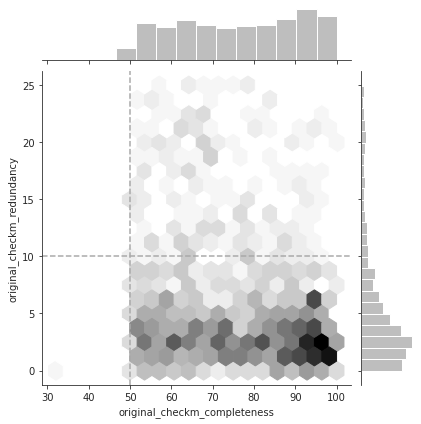

In [48]:
sns.set_style("ticks")
kws = {'s':50, 'alpha':0.2}
g = sns.jointplot(x="original_checkm_completeness", y="original_checkm_redundancy", 
                data=genome_dummy, color="darkgrey",
                height=6, ratio=5, kind="hex")#kind="scatter", **kws)
plt.axvline(50, ls="--", c="darkgrey")
plt.axhline(10, ls="--", c="darkgrey")
#plt.xlim([30,100])
plt.savefig(rootdir + "figures/original_marginal.svg", format="svg")
plt.show()

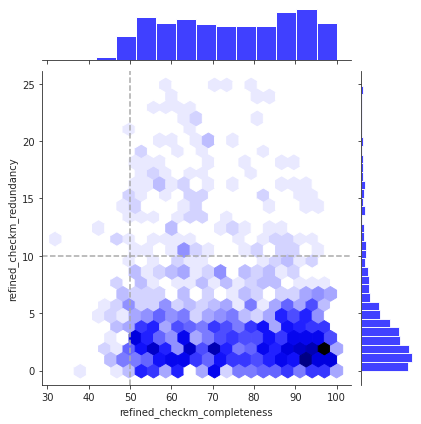

In [49]:
sns.set_style("ticks")
kws = {'s':50, 'alpha':0.2}
g = sns.jointplot(x="refined_checkm_completeness", y="refined_checkm_redundancy", 
                data=genome_table, color="#0000ff",
                kind="hex", height=6, ratio=5)
plt.axvline(50, ls="--",c="darkgrey")
plt.axhline(10, ls="--", c="darkgrey")
#plt.xlim([30,100])
plt.savefig(rootdir + "figures/refined_marginal.svg", format="svg")
plt.show()

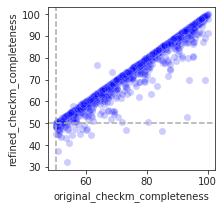

In [50]:
sns.set_style("ticks")
plt.figure(figsize=[3,3])
kws = {'s':50, 'alpha':0.2}
sns.scatterplot(
    x="original_checkm_completeness", 
    y="refined_checkm_completeness",
    data=genome_table, color="#0000ff", **kws
)
plt.axvline(50, ls="--",c="darkgrey")
plt.axhline(50, ls="--", c="darkgrey")
plt.savefig(rootdir + "figures/completeness_scatter.svg", format="svg")
plt.show()

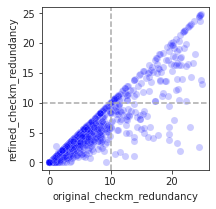

In [51]:
sns.set_style("ticks")
plt.figure(figsize=[3,3])
kws = {'s':50, 'alpha':0.2}
sns.scatterplot(
    x="original_checkm_redundancy", 
    y="refined_checkm_redundancy",
    data=genome_table, color="#0000ff", **kws
)
plt.axvline(10, ls="--",c="darkgrey")
plt.axhline(10, ls="--", c="darkgrey")
plt.savefig(rootdir + "figures/redundancy_scatter.svg", format="svg")
plt.show()

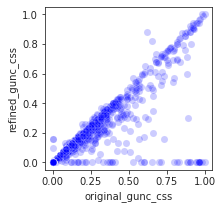

In [52]:
sns.set_style("ticks")
plt.figure(figsize=[3,3])
kws = {'s':50, 'alpha':0.2}
sns.scatterplot(
    x="original_gunc_css", 
    y="refined_gunc_css",
    data=genome_table, color="#0000ff", **kws
)
#plt.axvline(10, ls="--",c="darkgrey")
#plt.axhline(10, ls="--", c="darkgrey")
plt.savefig(rootdir + "figures/gunc_scatter.svg", format="svg")
plt.show()

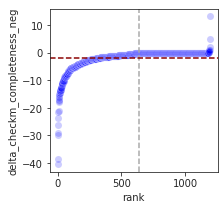

In [53]:
genome_table["delta_checkm_completeness_neg"] = genome_table["delta_checkm_completeness"].apply(lambda x: -1*x)
genome_sorted = genome_table.sort_values("delta_checkm_completeness_neg", ascending=True).reset_index()
genome_sorted["rank"] = genome_sorted.index

sns.set_style("ticks")
plt.figure(figsize=[3,3])
kws = {'s':50, 'alpha':0.2}
sns.scatterplot(
    x="rank", 
    y="delta_checkm_completeness_neg",
    data=genome_sorted, color="#0000ff", **kws
)
plt.axvline(genome_sorted.query("delta_checkm_completeness_neg==0")["rank"].iloc[0], ls="--",c="darkgrey")
plt.axhline(np.mean(genome_sorted["delta_checkm_completeness_neg"]), ls="--",c="darkred")
plt.savefig(rootdir + "figures/completeness_curve.svg", format="svg")
plt.show()

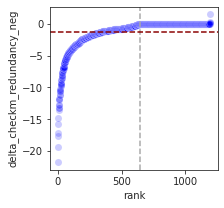

In [55]:
genome_table["delta_checkm_redundancy_neg"] = genome_table["delta_checkm_redundancy"].apply(lambda x: -1*x)
genome_sorted = genome_table.sort_values("delta_checkm_redundancy_neg", ascending=True).reset_index()
genome_sorted["rank"] = genome_sorted.index

sns.set_style("ticks")
plt.figure(figsize=[3,3])
kws = {'s':50, 'alpha':0.2}
sns.scatterplot(
    x="rank", 
    y="delta_checkm_redundancy_neg",
    data=genome_sorted, color="#0000ff", **kws
)
plt.axvline(genome_sorted.query("delta_checkm_redundancy_neg==0")["rank"].iloc[0], ls="--",c="darkgrey")
plt.axhline(np.mean(genome_sorted["delta_checkm_redundancy_neg"]), ls="--",c="darkred")
plt.savefig(rootdir + "figures/redundancy_curve.svg", format="svg")
plt.show()

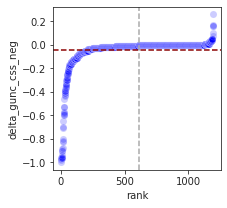

In [57]:
genome_table["delta_gunc_css_neg"] = genome_table["delta_gunc_css"].apply(lambda x: -1*x)
genome_sorted = genome_table.sort_values("delta_gunc_css_neg", ascending=True).reset_index()
genome_sorted["rank"] = genome_sorted.index

sns.set_style("ticks")
plt.figure(figsize=[3,3])
kws = {'s':50, 'alpha':0.2}
sns.scatterplot(
    x="rank", 
    y="delta_gunc_css_neg",
    data=genome_sorted, color="#0000ff", **kws
)
plt.axvline(genome_sorted.query("delta_gunc_css_neg==0")["rank"].iloc[0], ls="--",c="darkgrey")
plt.axhline(np.mean(genome_sorted["delta_gunc_css_neg"]), ls="--",c="darkred")
plt.savefig(rootdir + "figures/gunc_curve.svg", format="svg")
plt.show()